<a href="https://colab.research.google.com/github/Bessa1/PROJETO_IA_CARDIO_PREDICT/blob/main/projeto_ar3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
from google.colab import drive
drive.mount('/content/drive') # Monta o Google Drive no ambiente Colab

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [27]:
import pandas as pd

# Carrega o dataset com o separador de ponto e vírgula
df = pd.read_csv('/content/drive/MyDrive/cardio_train.csv', sep=';')

# Exibe as primeiras 5 linhas do DataFrame
display(df.head())

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [28]:
# Atualiza o caminho para carregar o conjunto de dados do Google Drive
df = pd.read_csv('/content/drive/MyDrive/cardio_train.csv', sep=';')

# Exibe as primeiras 5 linhas do DataFrame
display(df.head())

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [29]:
# Converte a idade de dias para anos
df['age_years'] = (df['age'] / 365).astype(int)

# Calcula o IMC (Índice de Massa Corporal)
# a altura está em cm, converte para metros dividindo por 100
df['imc'] = df['weight'] / ((df['height'] / 100)**2)

# Calcula a Pressão de Pulso
df['pulse_pressure'] = df['ap_hi'] - df['ap_lo']

# Exibe as primeiras linhas com as novas features e verifica os tipos de dados
display(df.head())
display(df[['age_years', 'imc', 'pulse_pressure']].info())

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years,imc,pulse_pressure
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0,50,21.967120,30
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1,55,34.927679,50
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1,51,23.507805,60
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1,48,28.710479,50
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0,47,23.011177,40


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age_years       70000 non-null  int64  
 1   imc             70000 non-null  float64
 2   pulse_pressure  70000 non-null  int64  
dtypes: float64(1), int64(2)
memory usage: 1.6 MB


None

In [30]:
# Calcula a feature de interação idade-gênero
df['age_gender'] = df['age_years'] * df['gender']

# Exibe as primeiras linhas com a nova feature
display(df.head())

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years,imc,pulse_pressure,age_gender
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0,50,21.967120,30,100
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1,55,34.927679,50,55
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1,51,23.507805,60,51
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1,48,28.710479,50,96
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0,47,23.011177,40,47


In [31]:
# Remove colunas desnecessárias: 'id' e 'age' original (já que 'age_years' é usada)
df_processed = df.drop(['id', 'age'], axis=1)

# Define as features (X) e o alvo (y)
X = df_processed.drop('cardio', axis=1)
y = df_processed['cardio']

print(f"Shape de X: {X.shape}")
print(f"Shape de y: {y.shape}")
display(X.head())
display(y.head())

Shape de X: (70000, 14)
Shape de y: (70000,)


,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,age_years,imc,pulse_pressure,age_gender
0,2,168,62.0,110,80,1,1,0,0,1,50,21.967120,30,100
1,1,156,85.0,140,90,3,1,0,0,1,55,34.927679,50,55
2,1,165,64.0,130,70,3,1,0,0,0,51,23.507805,60,51
3,2,169,82.0,150,100,1,1,0,0,1,48,28.710479,50,96
4,1,156,56.0,100,60,1,1,0,0,0,47,23.011177,40,47


,cardio
0,0
1,1
2,1
3,1
4,0


In [32]:
from sklearn.model_selection import train_test_split

# Divide os dados em conjuntos de treinamento e teste (divisão 80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Shape de X_train: {X_train.shape}")
print(f"Shape de y_train: {y_train.shape}")
print(f"Shape de X_test: {X_test.shape}")
print(f"Shape de y_test: {y_test.shape}")

Shape de X_train: (56000, 14)
Shape de y_train: (56000,)
Shape de X_test: (14000, 14)
Shape de y_test: (14000,)


In [33]:
from sklearn.preprocessing import StandardScaler

# Inicializa o StandardScaler
scaler = StandardScaler()

# Ajusta o scaler aos dados de treinamento e transforma os dados de treinamento e teste
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Converte os arrays escalados de volta para DataFrame para melhor legibilidade e para reter os nomes das colunas
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print("Cabeçalho de X_train_scaled:")
display(X_train_scaled.head())
print("Cabeçalho de X_test_scaled:")
display(X_test_scaled.head())

Cabeçalho de X_train_scaled:


,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,age_years,imc,pulse_pressure,age_gender
0,1.365449,-0.284930,0.610019,-0.055968,-0.086783,-0.539408,-0.396073,-0.310319,-0.236614,-2.031452,-0.123660,0.656711,0.030994,1.225592
1,-0.732360,-0.771139,-0.710377,-0.055968,-0.086783,-0.539408,-0.396073,-0.310319,-0.236614,0.492259,-0.864172,-0.314112,0.030994,-0.904333
2,-0.732360,0.079728,1.443954,0.191632,0.016541,0.931371,-0.396073,-0.310319,-0.236614,0.492259,-0.123660,1.186445,0.110912,-0.717497
3,-0.732360,-0.041825,0.610019,0.129732,0.016541,-0.539408,-0.396073,-0.310319,-0.236614,0.492259,0.320647,0.532441,0.070953,-0.605396
4,-0.732360,-1.014244,-1.544312,-0.179769,-0.153944,-0.539408,-0.396073,-0.310319,-0.236614,-2.031452,-0.567967,-1.006144,0.003023,-0.829598


Cabeçalho de X_test_scaled:


,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,age_years,imc,pulse_pressure,age_gender
0,-0.732360,-1.135796,-1.023103,-0.055968,-0.060952,-0.539408,-0.396073,-0.310319,-0.236614,0.492259,0.024442,-0.455301,0.011015,-0.680130
1,-0.732360,-0.528034,-1.057850,0.005932,-0.035121,-0.539408,-0.396073,-0.310319,-0.236614,0.492259,0.616852,-0.733935,0.030994,-0.530662
2,1.365449,1.295251,0.957492,-0.055968,-0.086783,0.931371,-0.396073,-0.310319,-0.236614,0.492259,-1.752787,0.188011,0.030994,0.403516
3,1.365449,1.538356,-0.849366,-0.055968,-0.035121,-0.539408,-0.396073,-0.310319,-0.236614,0.492259,-0.271763,-1.261851,-0.008965,1.150858
4,-0.732360,0.322832,0.471030,-0.055968,-0.086783,-0.539408,-0.396073,-0.310319,-0.236614,0.492259,-0.567967,0.238099,0.030994,-0.829598


In [34]:
from sklearn.linear_model import LogisticRegression

# Inicializa e treina o modelo de Regressão Logística
log_reg_model = LogisticRegression(random_state=42, solver='liblinear')
log_reg_model.fit(X_train_scaled, y_train)

# Faz previsões no conjunto de teste escalado
y_pred_log_reg = log_reg_model.predict(X_test_scaled)

print("Modelo de Regressão Logística treinado e previsões realizadas.")

Modelo de Regressão Logística treinado e previsões realizadas.


In [35]:
from sklearn.ensemble import RandomForestClassifier

# Inicializa e treina o modelo Random Forest
# Usando 200 árvores e profundidade máxima de 15, conforme especificado no esboço do projeto
rf_model = RandomForestClassifier(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)

# Faz previsões no conjunto de teste escalado
y_pred_rf = rf_model.predict(X_test_scaled)

print("Modelo Random Forest treinado e previsões realizadas.")

Modelo Random Forest treinado e previsões realizadas.


In [36]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def evaluate_model(y_true, y_pred, y_proba=None, model_name="Modelo"):
    """Calcula e imprime métricas comuns de classificação."""
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    print(f"--- Métricas do {model_name} ---")
    print(f"Acurácia: {accuracy:.4f}")
    print(f"Precisão: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")

    if y_proba is not None:
        auc_roc = roc_auc_score(y_true, y_proba)
        print(f"AUC-ROC: {auc_roc:.4f}")
    print("\n")

# Obtém probabilidades para o cálculo do AUC-ROC
y_proba_log_reg = log_reg_model.predict_proba(X_test_scaled)[:, 1]
y_proba_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

# Avalia a Regressão Logística
evaluate_model(y_test, y_pred_log_reg, y_proba_log_reg, model_name="Regressão Logística")

# Avalia o Random Forest
evaluate_model(y_test, y_pred_rf, y_proba_rf, model_name="Random Forest")

--- Métricas do Regressão Logística ---
Acurácia: 0.7146
Precisão: 0.7324
Recall: 0.6757
F1-Score: 0.7029
AUC-ROC: 0.7779


--- Métricas do Random Forest ---
Acurácia: 0.7302
Precisão: 0.7494
Recall: 0.6913
F1-Score: 0.7192
AUC-ROC: 0.7954




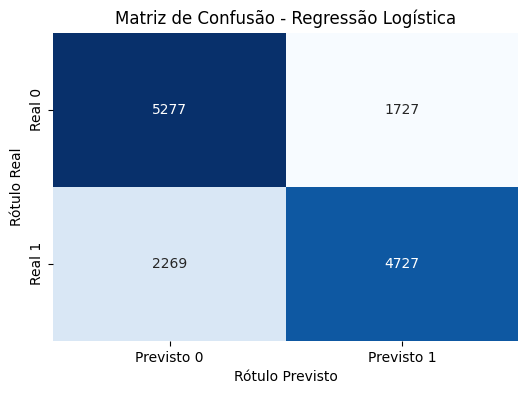

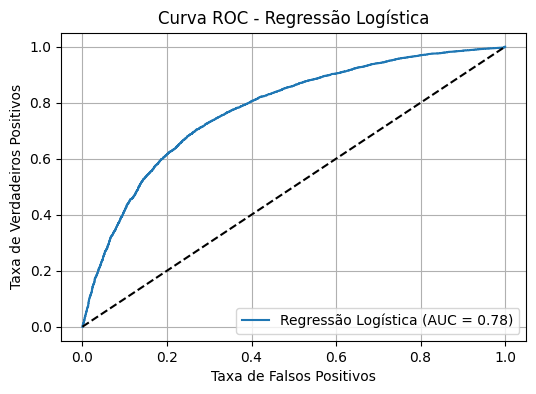

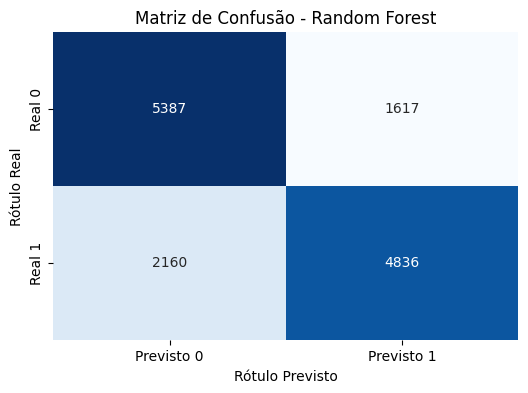

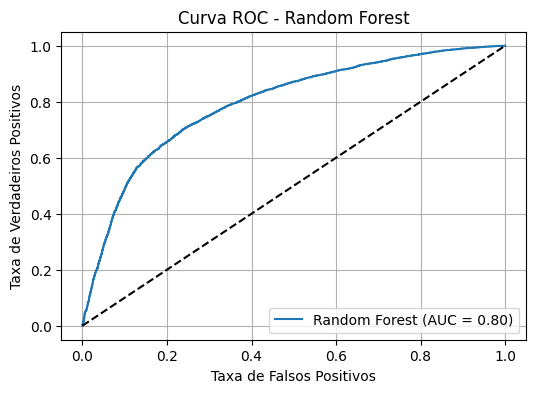

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve

def plot_confusion_matrix(y_true, y_pred, model_name="Modelo"):
    """Plota a matriz de confusão para um dado modelo."""
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Previsto 0', 'Previsto 1'],
                yticklabels=['Real 0', 'Real 1'])
    plt.title(f'Matriz de Confusão - {model_name}')
    plt.ylabel('Rótulo Real')
    plt.xlabel('Rótulo Previsto')
    plt.show()

def plot_roc_curve(y_true, y_proba, model_name="Modelo"):
    """Plota a curva ROC para um dado modelo."""
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    plt.figure(figsize=(6, 4))
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc_score(y_true, y_proba):.2f})')
    plt.plot([0, 1], [0, 1], 'k--') # Diagonal tracejada
    plt.xlabel('Taxa de Falsos Positivos')
    plt.ylabel('Taxa de Verdadeiros Positivos')
    plt.title(f'Curva ROC - {model_name}')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()

# Plota a Matriz de Confusão para a Regressão Logística
plot_confusion_matrix(y_test, y_pred_log_reg, model_name="Regressão Logística")

# Plota a Curva ROC para a Regressão Logística
plot_roc_curve(y_test, y_proba_log_reg, model_name="Regressão Logística")

# Plota a Matriz de Confusão para o Random Forest
plot_confusion_matrix(y_test, y_pred_rf, model_name="Random Forest")

# Plota a Curva ROC para o Random Forest
plot_roc_curve(y_test, y_proba_rf, model_name="Random Forest")

Top 10 Importâncias de Features do Random Forest:


,Feature,Importance
3,ap_hi,0.220471
4,ap_lo,0.136750
12,pulse_pressure,0.120364
11,imc,0.100665
10,age_years,0.096624
2,weight,0.077801
13,age_gender,0.066360
1,height,0.065662
5,cholesterol,0.062972
6,gluc,0.017501


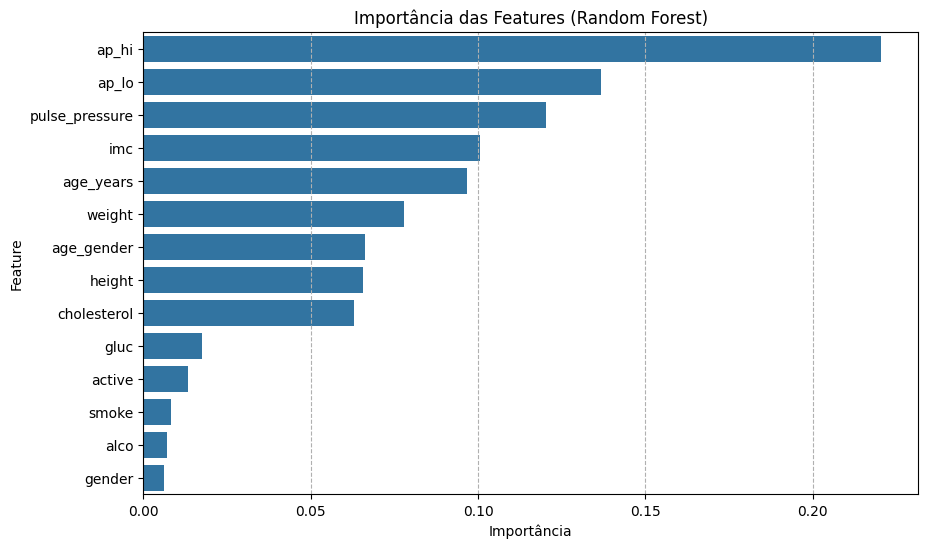

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Obtém as importâncias das features do modelo Random Forest
feature_importances = rf_model.feature_importances_

# Obtém os nomes das features dos dados de treinamento
feature_names = X_train.columns

# Cria um DataFrame para melhor visualização
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})

# Classifica as features por importância em ordem decrescente
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Exibe as N principais importâncias de features (por exemplo, as 10 principais)
print("Top 10 Importâncias de Features do Random Forest:")
display(importance_df.head(10))

# Plotagem das importâncias das features
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Importância das Features (Random Forest)')
plt.xlabel('Importância')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--')
plt.show()

In [39]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

# Inicializa a validação cruzada K-Fold estratificada
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("--- Resultados da Validação Cruzada ---")

# Realiza validação cruzada de 5-folds para a Regressão Logística
cv_scores_log_reg = cross_val_score(log_reg_model, X_train_scaled, y_train, cv=kfold, scoring='accuracy', n_jobs=-1)
print(f"Acurácia da Validação Cruzada (Regressão Logística): {cv_scores_log_reg.mean():.4f} (+/- {cv_scores_log_reg.std():.4f})")

# Realiza validação cruzada de 5-folds para o Random Forest
cv_scores_rf = cross_val_score(rf_model, X_train_scaled, y_train, cv=kfold, scoring='accuracy', n_jobs=-1)
print(f"Acurácia da Validação Cruzada (Random Forest): {cv_scores_rf.mean():.4f} (+/- {cv_scores_rf.std():.4f})")

--- Resultados da Validação Cruzada ---
Acurácia da Validação Cruzada (Regressão Logística): 0.7206 (+/- 0.0049)
Acurácia da Validação Cruzada (Random Forest): 0.7334 (+/- 0.0025)


## FASE 5: VISUALIZAÇÃO

Nesta fase, exploraremos os dados e o desempenho do modelo através de visualizações, tornando os insights mais acessíveis e compreensíveis.

### 5.1 Distribuição das Características Numéricas

Vamos visualizar a distribuição das características numéricas chave para entender sua dispersão, identificar possíveis vieses e verificar a presença de valores atípicos. Usaremos histogramas e gráficos de densidade (KDE).

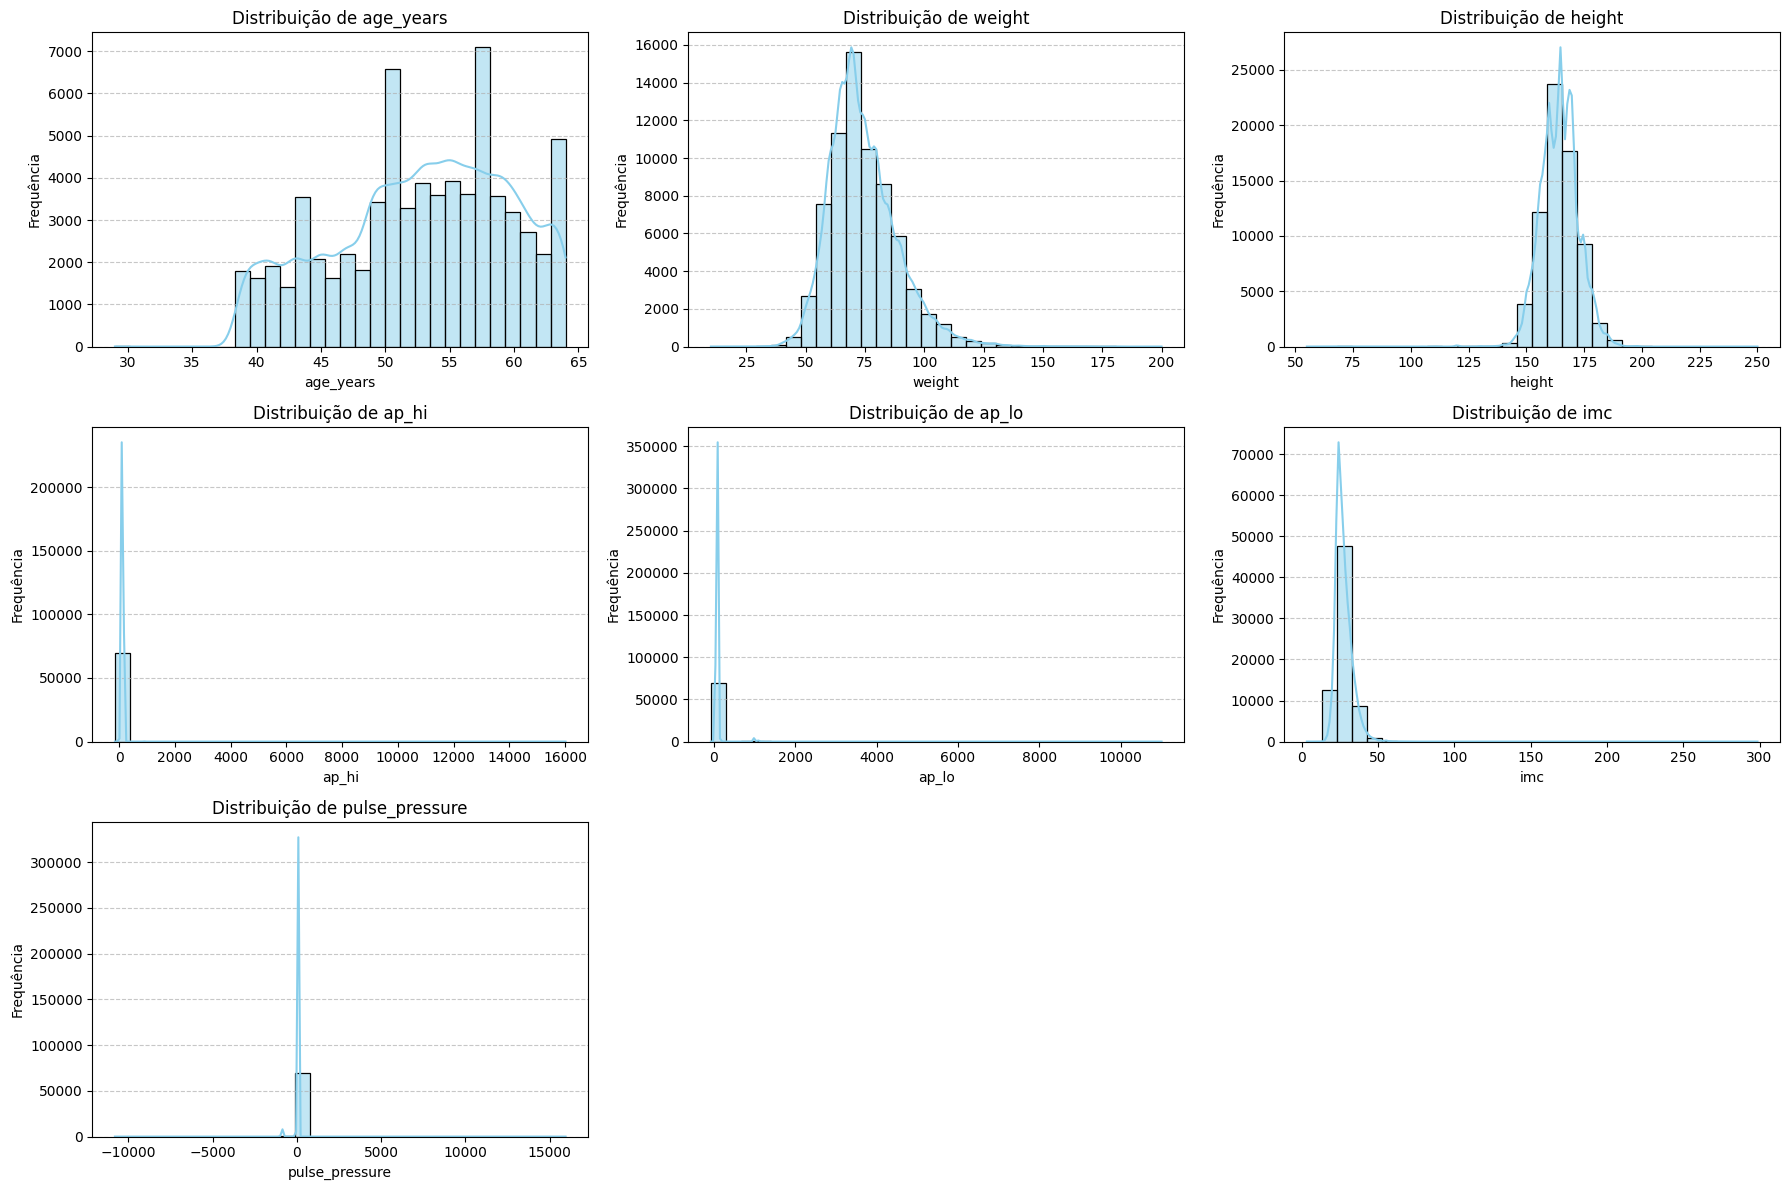

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

# Features para visualizar as distribuições
features_to_plot = ['age_years', 'weight', 'height', 'ap_hi', 'ap_lo', 'imc', 'pulse_pressure']

plt.figure(figsize=(18, 12))
for i, feature in enumerate(features_to_plot):
    plt.subplot(3, 3, i + 1) # Ajusta a grade do subplot conforme necessário
    sns.histplot(df_processed[feature], kde=True, bins=30, color='skyblue')
    plt.title(f'Distribuição de {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequência')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 5.2 Mapa de Calor de Correlação

Um mapa de calor de correlação nos ajudará a entender as relações lineares entre as diferentes características do nosso conjunto de dados, incluindo a variável alvo `cardio`.

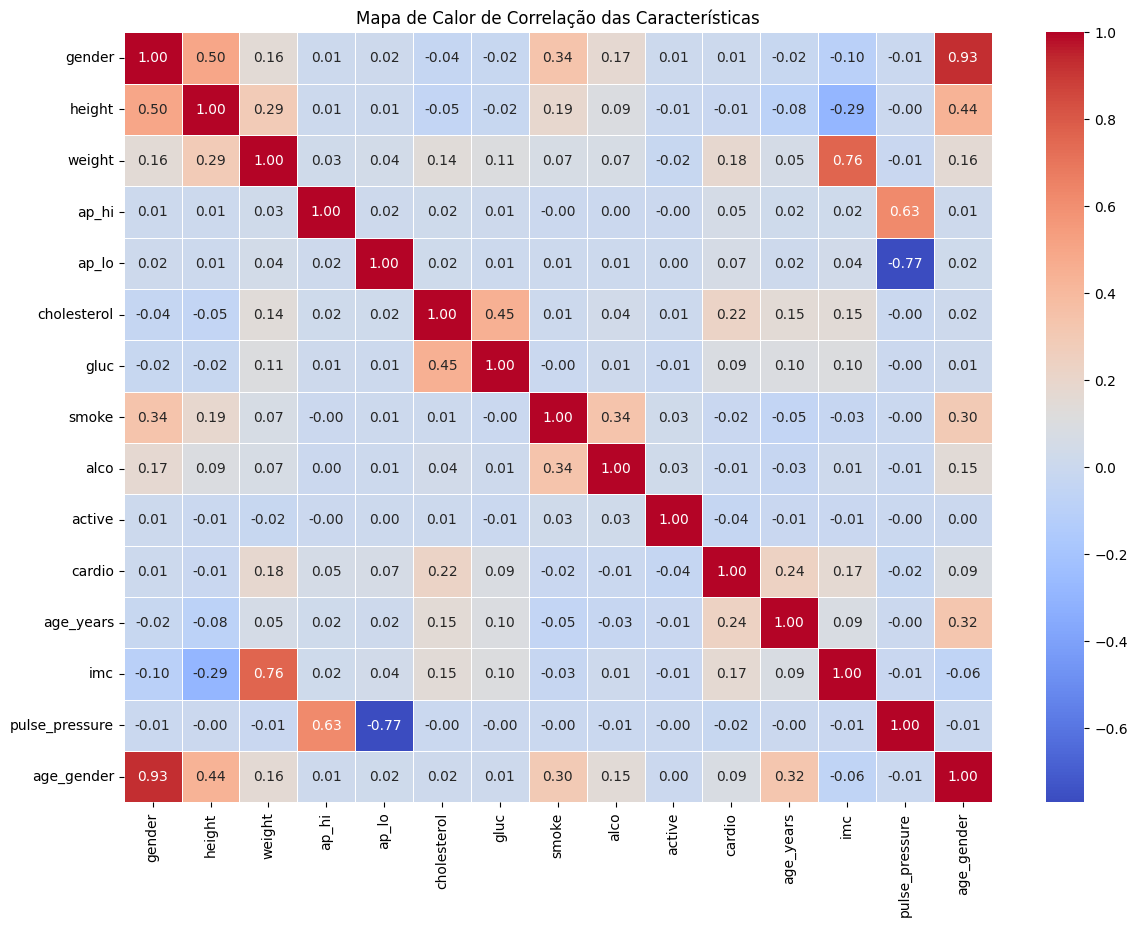

In [41]:
plt.figure(figsize=(14, 10))
sns.heatmap(df_processed.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Mapa de Calor de Correlação das Características')
plt.show()

### 5.3 Comparação Visual do Desempenho dos Modelos

Para facilitar a compreensão das diferenças de desempenho entre os modelos de Regressão Logística e Random Forest, vamos visualizar suas métricas de avaliação chave lado a lado.

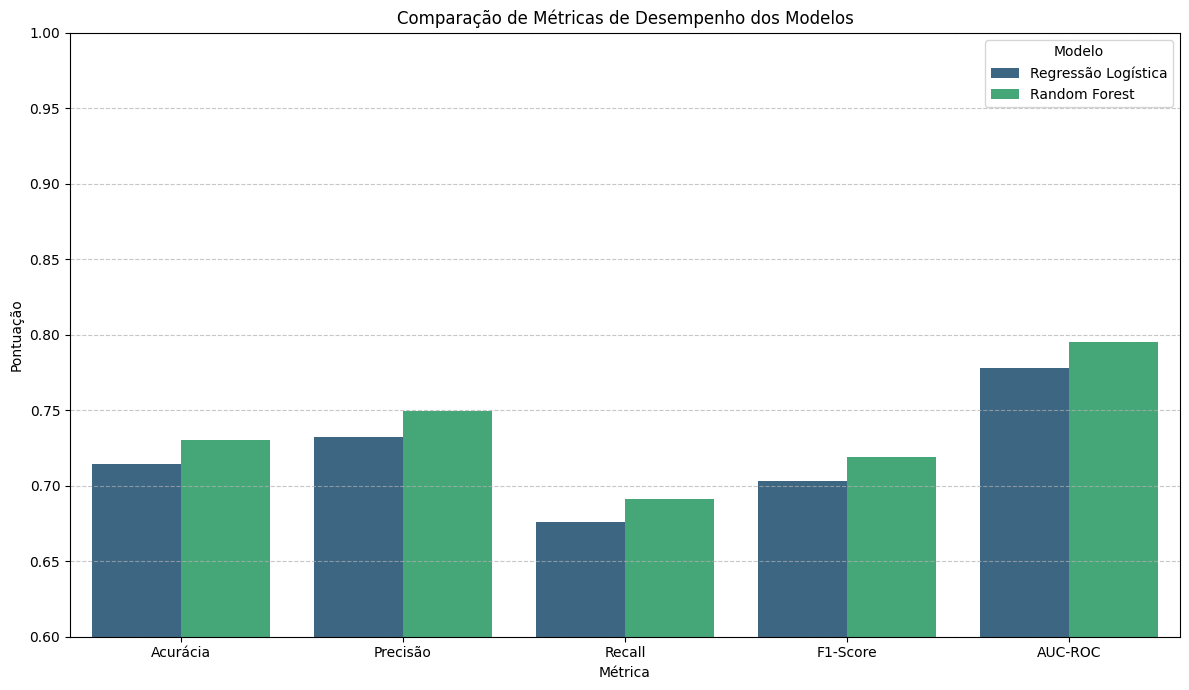

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Recalcula as métricas para garantir a consistência (ou usa valores previamente armazenados, se disponíveis)
# Métricas da Regressão Logística
log_reg_accuracy = accuracy_score(y_test, y_pred_log_reg)
log_reg_precision = precision_score(y_test, y_pred_log_reg)
log_reg_recall = recall_score(y_test, y_pred_log_reg)
log_reg_f1 = f1_score(y_test, y_pred_log_reg)
log_reg_auc_roc = roc_auc_score(y_test, y_proba_log_reg)

# Métricas do Random Forest
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)
rf_auc_roc = roc_auc_score(y_test, y_proba_rf)

# Cria um DataFrame para comparação
metrics_data = {
    'Métrica': ['Acurácia', 'Precisão', 'Recall', 'F1-Score', 'AUC-ROC'],
    'Regressão Logística': [log_reg_accuracy, log_reg_precision, log_reg_recall, log_reg_f1, log_reg_auc_roc],
    'Random Forest': [rf_accuracy, rf_precision, rf_recall, rf_f1, rf_auc_roc]
}
metrics_df = pd.DataFrame(metrics_data)

# 'Derrete' o DataFrame para facilitar a plotagem com seaborn
metrics_df_melted = metrics_df.melt('Métrica', var_name='Modelo', value_name='Pontuação')

plt.figure(figsize=(12, 7))
sns.barplot(x='Métrica', y='Pontuação', hue='Modelo', data=metrics_df_melted, palette='viridis')
plt.title('Comparação de Métricas de Desempenho dos Modelos')
plt.ylabel('Pontuação')
plt.xlabel('Métrica')
plt.ylim(0.6, 1.0) # Define um limite y razoável para scores de classificação
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Modelo')
plt.tight_layout()
plt.show()